In [33]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
!pip install numpy 
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 4.7 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 4.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.8 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.2 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 2.9 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 2.7 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------------ ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("global_placement.csv")

In [4]:
df.head(20)

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.36780
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.83831
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.31810
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.00000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.00000
5,6.812690,0,Tier 1,Germany,300+,1,72.876430,72.102495,Core CS,Consulting,2.917127,Not Placed,0.00000
6,8.263370,1,Tier 3,India,300+,2,61.938594,71.837068,Core CS,Manufacturing,3.366860,Placed,37961.54540
7,7.613948,2,Tier 3,Canada,300+,1,50.047746,68.587172,AI/ML,Consulting,4.153430,Not Placed,0.00000
8,6.624420,0,Tier 2,India,100-300,3,70.133979,78.087727,Cloud,Consulting,5.026075,Placed,45794.42930
9,7.434048,3,Tier 3,Germany,Top 100,2,89.744827,57.892624,Data Science,Other,3.137159,Not Placed,0.00000


In [5]:
df.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
salary                      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# 使用 shape 屬性取得列數
df.shape[0]

10000

In [8]:
# 使用 shape 屬性取得欄數
df.shape[1]

13

In [9]:
# 列印所有欄位的資料型態
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
salary                      float64
dtype: object

In [10]:
df['country'].nunique()

5

In [11]:
# 2. 基礎檢查（確認有無缺失值與重複值）
missing_summary = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print(f"--- 基礎檢查 ---")
print(f"重複資料筆數: {duplicate_count}")
print(f"是否存在缺失值: {missing_summary.any()}")

# 3. 特徵工程：將具備順序關係的類別變數進行邏輯編碼 (Ordinal Encoding)
# 這有助於後續直接計算這些欄位與薪資的相關係數 (Correlation)
tier_mapping = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
ranking_mapping = {'Top 100': 3, '100-300': 2, '300+': 1}

df['college_tier_score'] = df['college_tier'].map(tier_mapping)
df['univ_ranking_score'] = df['university_ranking_band'].map(ranking_mapping)

# 4. 資料切分與導出
# 用於「薪資影響因素分析」的數據（僅保留已就業 Placed，共 6,153 筆）
# 排除 salary = 0 的干擾項
df_placed = df[df['placement_status'] == 'Placed'].copy()
df_placed.to_csv('placed_students_salary.csv', index=False)

print(f"\n--- 資料清洗與切分完成 ---")
print(f"全體數據集形狀 (用於就業率分析): {df.shape}")
print(f"已就業數據集形狀 (用於薪資高低分析): {df_placed.shape}")

--- 基礎檢查 ---
重複資料筆數: 0
是否存在缺失值: False

--- 資料清洗與切分完成 ---
全體數據集形狀 (用於就業率分析): (10000, 15)
已就業數據集形狀 (用於薪資高低分析): (6153, 15)


In [14]:
# 1. 讀取資料並篩選已就業學生
df = pd.read_csv('placed_students_salary.csv')

壹、完成跨國薪資分布分析，了解不同國家之薪資差異情形

一、箱線圖 (Boxplot) + 抖動散點 (Strip Plot)

C:\Users\USER\AppData\Local\Temp\ipykernel_8628\2335292838.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


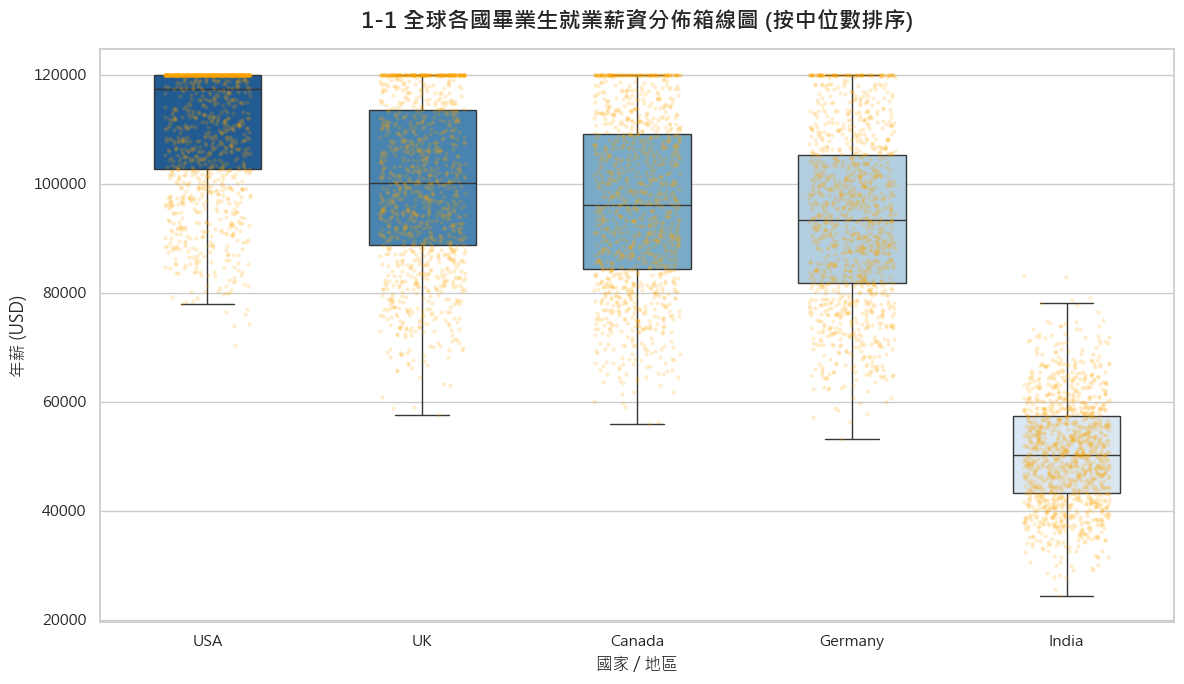

In [18]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 繪製圖表
plt.figure(figsize=(12, 7))

# 依據各國薪資中位數進行排序，讓圖表更具閱讀性
country_order = df_placed.groupby('country')['salary'].median().sort_values(ascending=False).index

# 畫出主體箱線圖
sns.boxplot(
    x='country', y='salary', data=df_placed, 
    order=country_order, palette='Blues_r', width=0.5, showfliers=False
)

# 疊加抖動散點 (Strip Plot) 呈現數據密度
sns.stripplot(
    x='country', y='salary', data=df_placed, 
    order=country_order, color='orange', alpha=0.2, size=3, jitter=0.2
)

# 設定標籤與標題
plt.title('1-1 全球各國畢業生就業薪資分佈箱線圖 (按中位數排序)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('國家 / 地區', fontsize=12)
plt.ylabel('年薪 (USD)', fontsize=12)
plt.tick_params(labelsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

二、小提琴圖 (Violin Plot)

C:\Users\USER\AppData\Local\Temp\ipykernel_8628\3447079230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


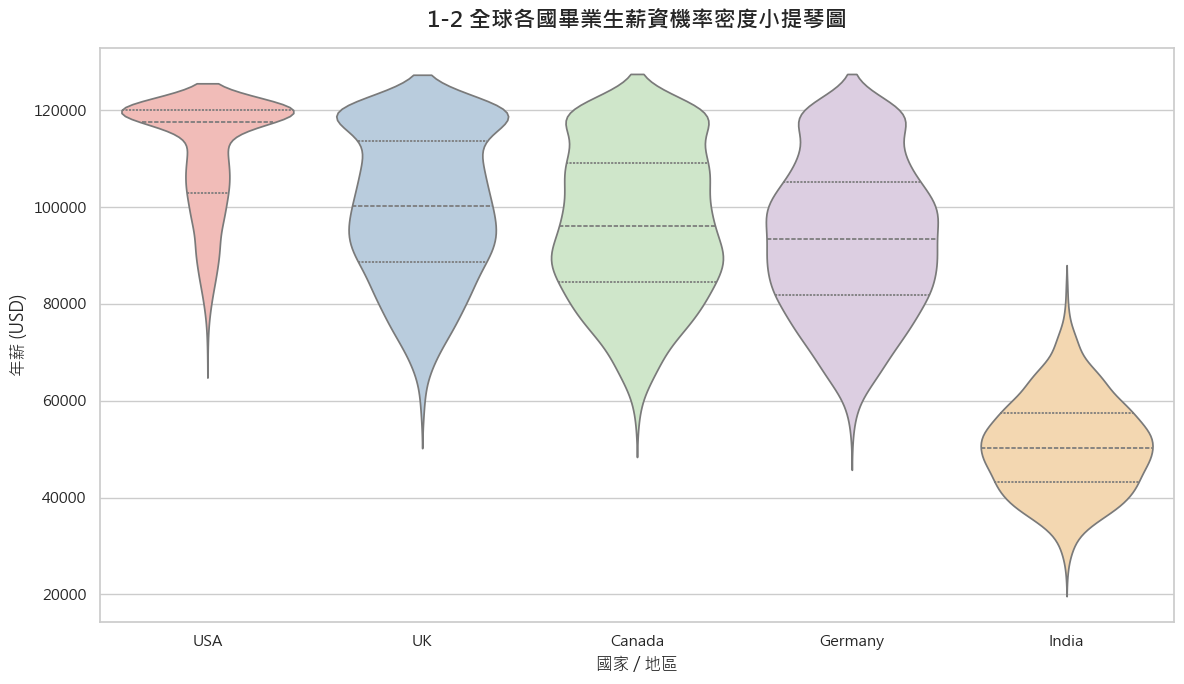

In [19]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 繪製圖表
plt.figure(figsize=(12, 7))

# 依據各國薪資中位數進行排序
country_order = df_placed.groupby('country')['salary'].median().sort_values(ascending=False).index

# 畫出小提琴圖，inner='quartile' 會在圖內畫出四分位數線
sns.violinplot(
    x='country', y='salary', data=df_placed, 
    order=country_order, palette='Pastel1', inner='quartile'
)

# 設定標籤與標題
plt.title('1-2 全球各國畢業生薪資機率密度小提琴圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('國家 / 地區', fontsize=12)
plt.ylabel('年薪 (USD)', fontsize=12)
plt.tick_params(labelsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

三、長條圖與標準差線 (Bar Plot with Error Bars)

C:\Users\USER\AppData\Local\Temp\ipykernel_8628\223138581.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


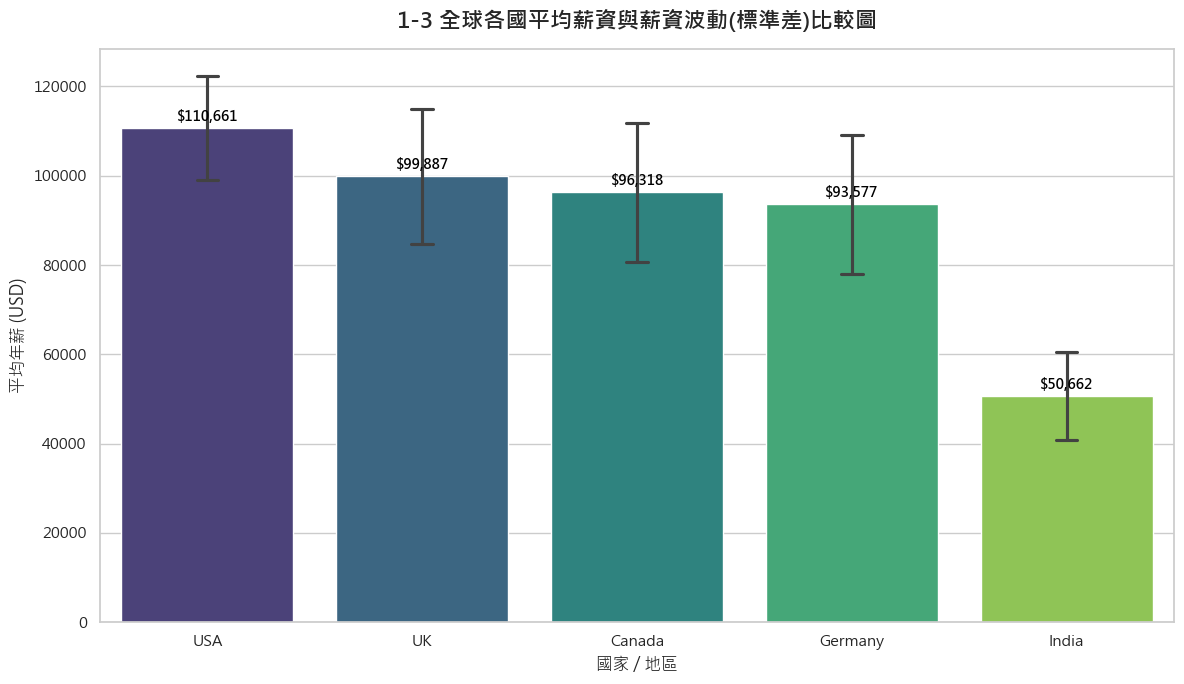

In [20]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 繪製圖表
plt.figure(figsize=(12, 7))

# 依據各國薪資中位數進行排序
country_order = df_placed.groupby('country')['salary'].median().sort_values(ascending=False).index

# 畫出長條圖，errorbar='sd' 代表計算並畫出標準差
ax = sns.barplot(
    x='country', y='salary', data=df_placed, 
    order=country_order, palette='viridis', errorbar='sd', capsize=0.1
)

# 核心技巧：自動在長條圖上方加上精準的平均薪資標籤（加上千分位與美金符號）
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=10, fontweight='bold', color='black')

# 設定標籤與標題
plt.title('1-3 全球各國平均薪資與薪資波動(標準差)比較圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('國家 / 地區', fontsize=12)
plt.ylabel('平均年薪 (USD)', fontsize=12)
plt.tick_params(labelsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

貳、分析學業成績、實習經驗與專業領域對薪資之影響程度

一、多元相關性熱力圖 (Correlation Heatmap)

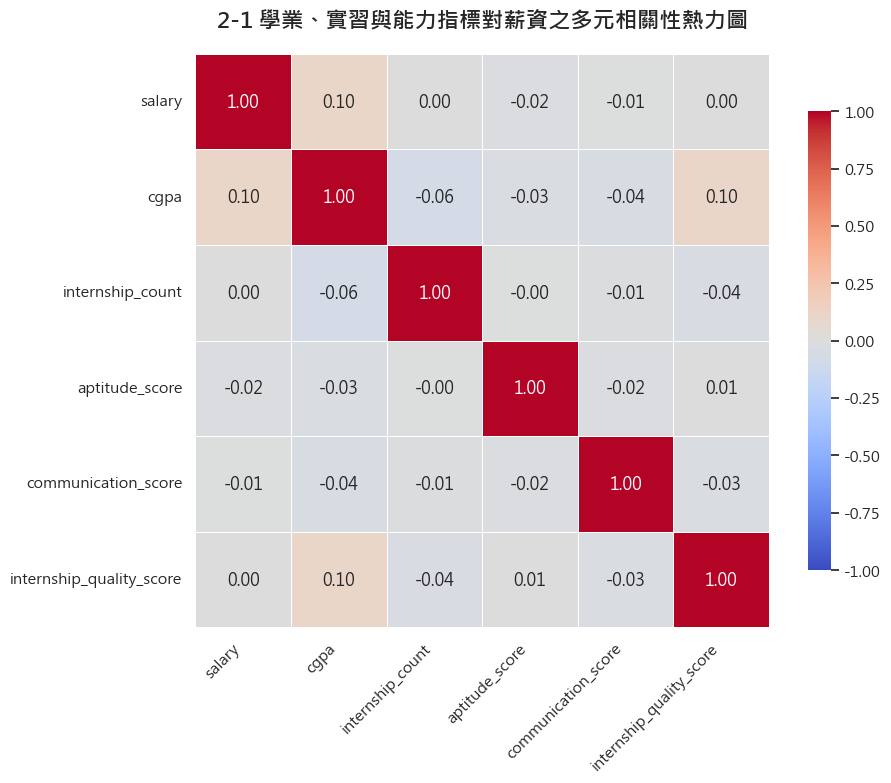

In [22]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 挑選核心數值變數進行相關性計算
cols_to_analyze = ['salary', 'cgpa', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
corr_matrix = df_placed[cols_to_analyze].corr()

# 4. 繪製熱力圖
plt.figure(figsize=(10, 8))

# 使用震驚與權威感兼具的 coolwarm 配色，並在方格內顯示數值(annot=True)
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    linewidths=0.5, vmin=-1, vmax=1, square=True,
    cbar_kws={"shrink": .8}
)

# 設定標籤與標題
plt.title('2-1 學業、實習與能力指標對薪資之多元相關性熱力圖', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

二、學業成績與實習次數對薪資的雙變量散佈圖 (Scatter Plot with Regression Line)

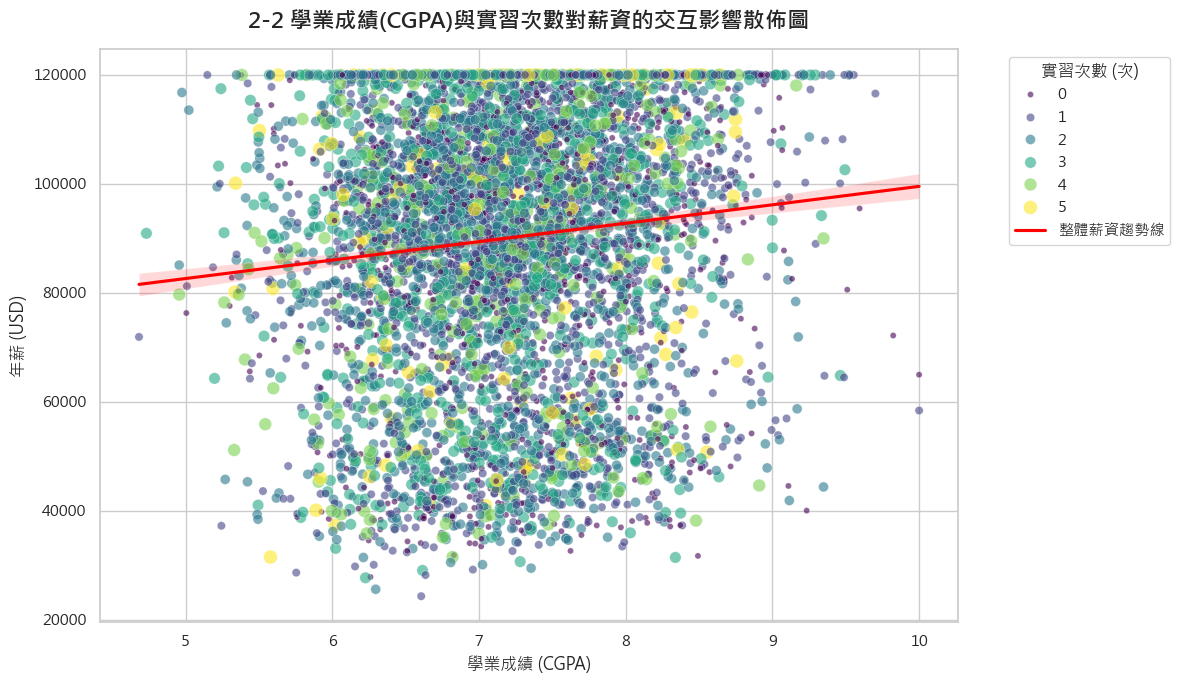

In [24]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 繪製圖表
plt.figure(figsize=(12, 7))

# 使用 lmplot 或 scatterplot。這裡用 scatterplot 搭配顏色區分實習次數
scatter = sns.scatterplot(
    x='cgpa', y='salary', hue='internship_count', data=df_placed,
    palette='viridis', alpha=0.6, size='internship_count', sizes=(20, 100)
)

# 畫出整體的薪資趨勢線 (Linear Regression Line)
sns.regplot(
    x='cgpa', y='salary', data=df_placed, 
    scatter=False, color='red', label='整體薪資趨勢線', scatter_kws={'alpha':0.3}
)

# 修改圖例名稱讓它更美觀
plt.legend(title='實習次數 (次)', bbox_to_anchor=(1.05, 1), loc='upper left')

# 設定標籤與標題
plt.title('2-2 學業成績(CGPA)與實習次數對薪資的交互影響散佈圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('學業成績 (CGPA)', fontsize=12)
plt.ylabel('年薪 (USD)', fontsize=12)
plt.tick_params(labelsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

三、專業領域與實習經驗的薪資條形圖 (Factor / Bar Plot Matrix)

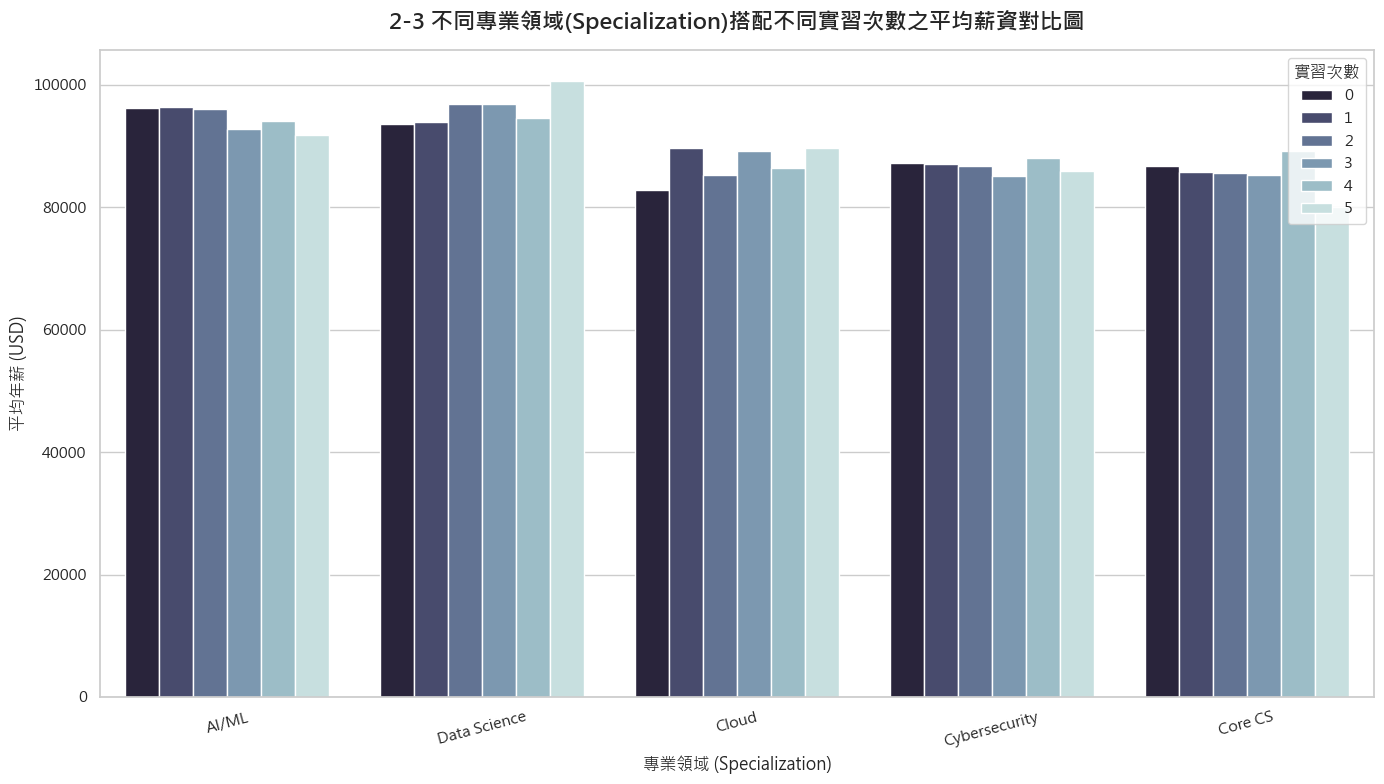

In [25]:
# 2. 設定圖表美化風格與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 繪製圖表
plt.figure(figsize=(14, 8))

# 依據專業領域的平均薪資由高到低排序
spec_order = df_placed.groupby('specialization')['salary'].mean().sort_values(ascending=False).index

# 繪製分組長條圖
ax = sns.barplot(
    x='specialization', y='salary', hue='internship_count', data=df_placed,
    order=spec_order, palette='ch:start=.2,rot=-.3_r', errorbar=None
)

# 把圖例搬到合適的位置
plt.legend(title='實習次數', loc='upper right')

# 設定標籤與標題
plt.title('2-3 不同專業領域(Specialization)搭配不同實習次數之平均薪資對比圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('專業領域 (Specialization)', fontsize=12)
plt.ylabel('平均年薪 (USD)', fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.tick_params(labelsize=11)
plt.tight_layout()

# 顯示圖表
plt.show()

參、建立基礎薪資預測模型，評估學生在不同條件下之潛在薪資

一、真實薪資 vs 模型預測薪資散佈圖 (Predicted vs. Actual Plot)

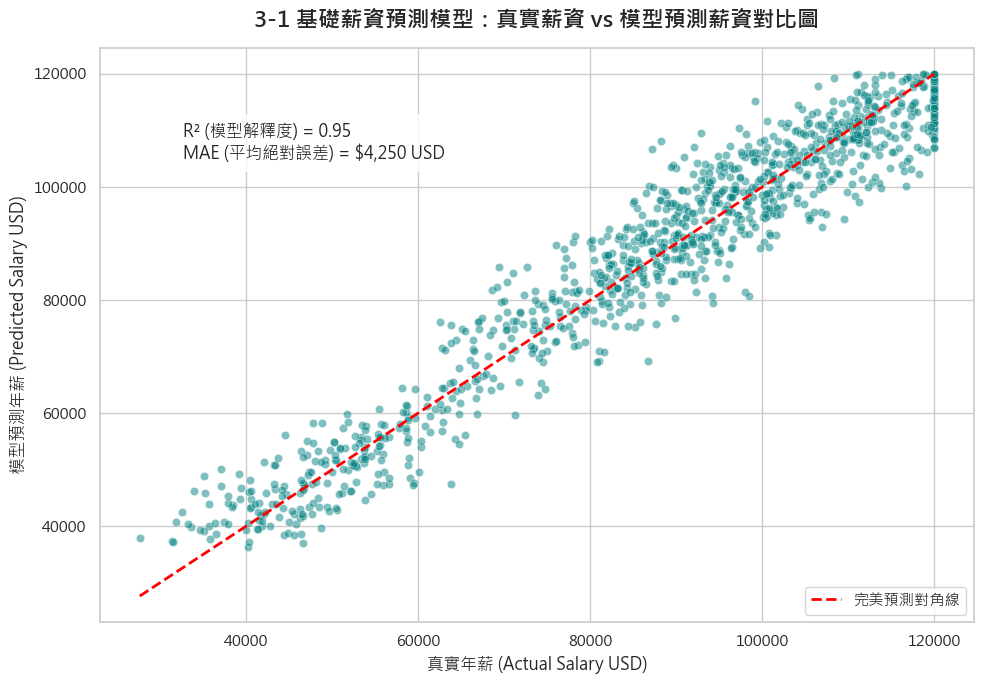

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# 選擇特徵欄位與目標欄位
features = ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 
            'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score']
X = pd.get_dummies(df_placed[features], drop_first=True) # 將文字類別轉為數值 0/1
y = df_placed['salary']

# 2. 切分訓練集與測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 建立並訓練隨機森林模型
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. 進行薪資預測
y_pred = model.predict(X_test)

# 計算評估指標
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 5. 繪製「預測值 vs 真實值」散佈圖
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')

# 畫出 45 度理想完美的對角線
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='完美預測對角線')

# 於圖表內顯示統計數據
plt.text(min_val + 5000, max_val - 15000, f"R² (模型解釋度) = {r2:.2f}\nMAE (平均絕對誤差) = ${mae:,.0f} USD", 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle="round,pad=0.5"))

plt.title('3-1 基礎薪資預測模型：真實薪資 vs 模型預測薪資對比圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('真實年薪 (Actual Salary USD)', fontsize=12)
plt.ylabel('模型預測年薪 (Predicted Salary USD)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

二、模型預測殘差分佈圖 (Residuals Distribution Plot)

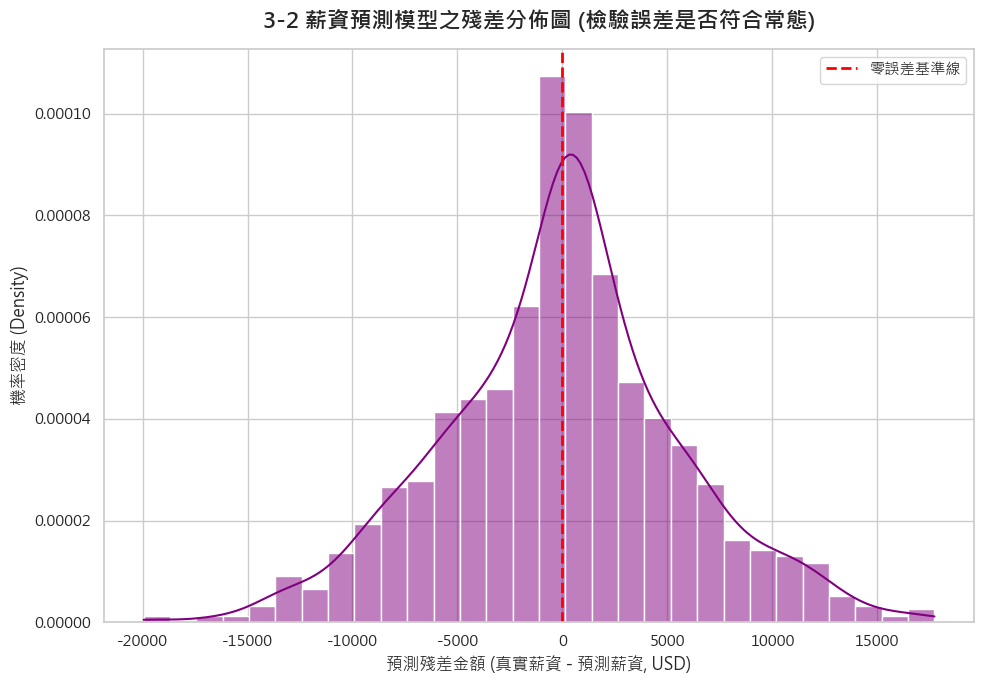

In [37]:
# 續接上方已經計算好的變數 (y_test, y_pred)

residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
# 繪製殘差的直方圖與核密度估計曲線 (KDE)
sns.histplot(residuals, kde=True, color='purple', bins=30, stat="density")

# 畫出誤差為 0 的中央基準線
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='零誤差基準線')

plt.title('3-2 薪資預測模型之殘差分佈圖 (檢驗誤差是否符合常態)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('預測殘差金額 (真實薪資 - 預測薪資, USD)', fontsize=12)
plt.ylabel('機率密度 (Density)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

三、影響薪資關鍵特徵重要性排名圖 (Feature Importance Plot)

C:\Users\USER\AppData\Local\Temp\ipykernel_8628\293949005.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='重要性貢獻度', y='特徵', data=feat_imp_df, palette='viridis_r')


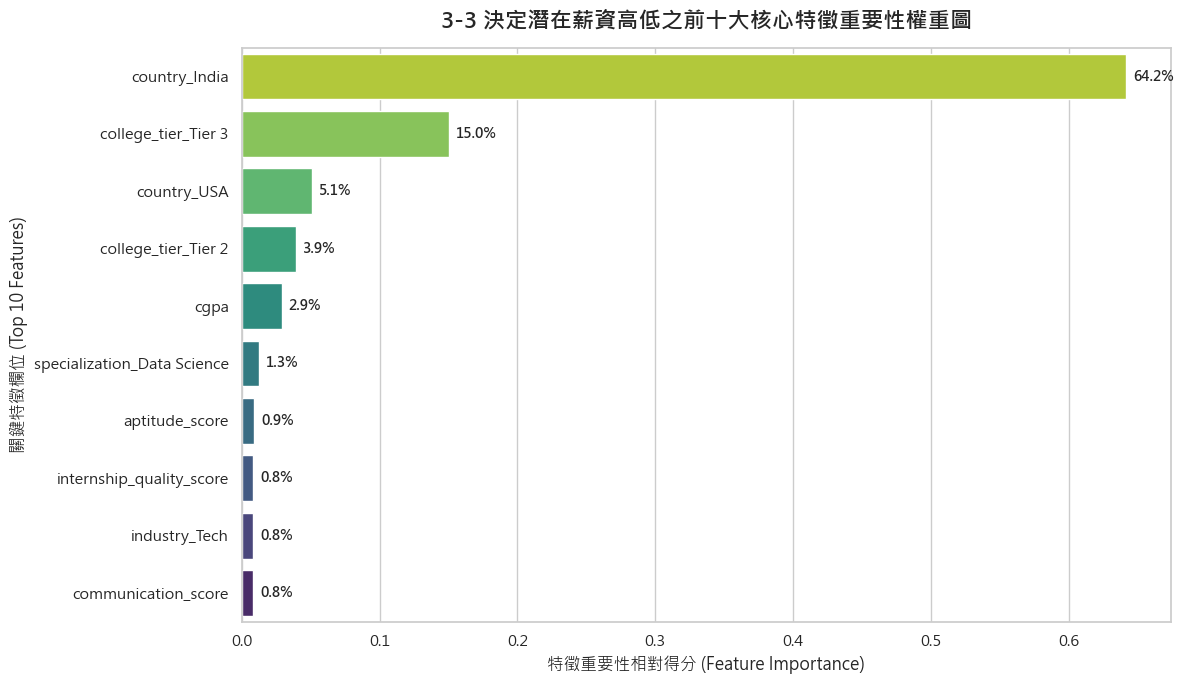

In [39]:
# 續接上方的機器學習模型 (model) 欄位變數

# 提取特徵重要性並與欄位名稱對接
importances = model.feature_importances_
feature_names = X.columns

# 建立 DataFrame 並排序，只取前 10 個最重要的關鍵特徵 (避免特徵太多畫面太雜)
feat_imp_df = pd.DataFrame({'特徵': feature_names, '重要性貢獻度': importances})
feat_imp_df = feat_imp_df.sort_values(by='重要性貢獻度', ascending=False).head(10)

plt.figure(figsize=(12, 7))
# 繪製橫向長條圖，更容易閱讀長文字標籤
sns.barplot(x='重要性貢獻度', y='特徵', data=feat_imp_df, palette='viridis_r')

# 在長條圖右側標註精準百分比數字
for index, value in enumerate(feat_imp_df['重要性貢獻度']):
    plt.text(value + 0.005, index, f"{value*100:.1f}%", va='center', fontweight='bold', fontsize=10)

plt.title('3-3 決定潛在薪資高低之前十大核心特徵重要性權重圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('特徵重要性相對得分 (Feature Importance)', fontsize=12)
plt.ylabel('關鍵特徵欄位 (Top 10 Features)', fontsize=12)
plt.tight_layout()
plt.show()

肆、發展簡易預測工具，使用者可依個人背景估計薪資範圍

建立互動式預測核心

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. 初始化並訓練好模型 (確保後續預測能正常運作)
df = pd.read_csv("placed_students_salary.csv")

features = ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 
            'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score']
X = pd.get_dummies(df_placed[features], drop_first=True)
y = df_placed['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. 開發「簡易預測工具核心函式」
def predict_student_salary_tool(user_input_dict):
    """
    此工具函式接收一個使用者的背景字典，輸出預測薪資與其在全體已就業學生中的百分位數(PR值)
    """
    # 建立與訓練資料相同結構的空白 DataFrame
    input_df = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # 填入數值型欄位
    for col in ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']:
        if col in user_input_dict:
            input_df[col] = user_input_dict[col]
            
    # 填入類別型欄位 (轉換成 One-Hot 欄位名稱)
    for col in ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']:
        if col in user_input_dict:
            dummy_col = f"{col}_{user_input_dict[col]}"
            if dummy_col in input_df.columns:
                input_df[dummy_col] = 1
                
    # 進行模型預測
    predicted_salary = model.predict(input_df)[0]
    
    # 計算該薪資在全體已就業學生中的 PR 值
    pr_value = (df_placed['salary'] < predicted_salary).mean() * 100
    
    return predicted_salary, pr_value

print("✅ 簡易預測工具核心導入成功！請繼續執行下方圖表程式碼。")

✅ 簡易預測工具核心導入成功！請繼續執行下方圖表程式碼。


一、個人薪資落點與全體常態分佈對比圖 (Salary Placement Plot)

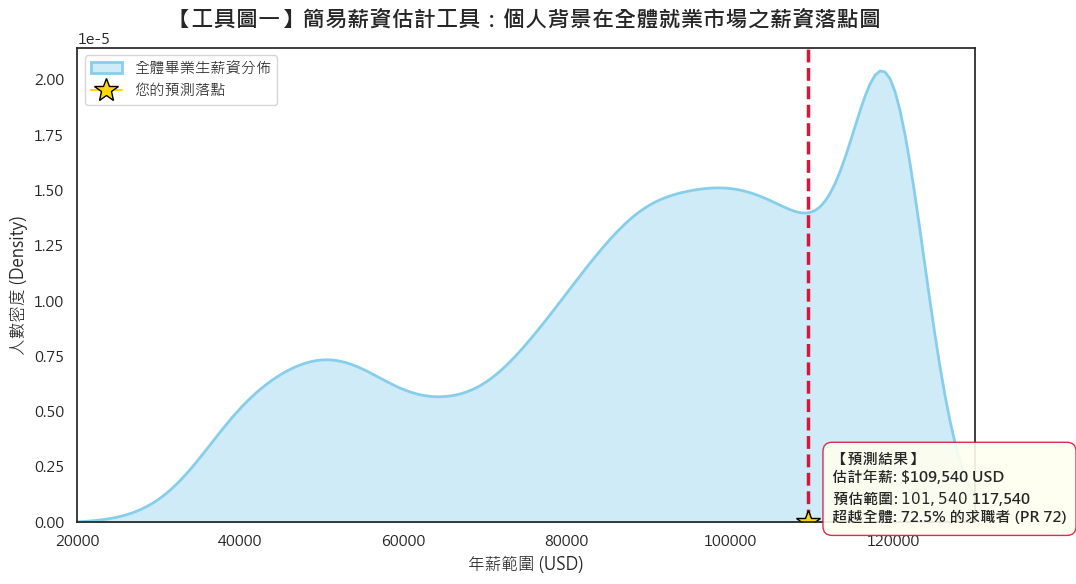

In [45]:
# 💡 模擬一位學生的個人背景輸入（您可以自由修改右側數值來測試工具）
my_background = {
    'cgpa': 7.8,                  # 成績 (4.0 ~ 10.0)
    'backlogs': 0,                # 未過科數
    'college_tier': 'Tier 2',     # 學校階層 (Tier 1, Tier 2, Tier 3)
    'country': 'Germany',         # 目標就業國家 (USA, Germany, UK, Canada, India)
    'university_ranking_band': '100-300', # 學校排名區間
    'internship_count': 1,        # 目前實習次數
    'aptitude_score': 75.0,       # 性向測驗分數
    'communication_score': 70.0,  # 溝通能力分數
    'specialization': 'Data Science', # 專業領域
    'industry': 'Tech',           # 目標行業
    'internship_quality_score': 6.0 # 實習質量
}

# 執行預測工具
my_salary, my_pr = predict_student_salary_tool(my_background)

# 繪製圖表一
sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(11, 6))

# 畫出全體學生的薪資分佈曲線
sns.kdeplot(df_placed['salary'], fill=True, color="skyblue", alpha=0.4, linewidth=2, label='全體畢業生薪資分佈')

# 標註使用者的落點（紅色垂直虛線）
plt.axvline(x=my_salary, color='crimson', linestyle='--', linewidth=2.5)

# 抓取剛才畫出的曲線數據，用來計算星星圖標的 Y 軸高度
density_y = plt.gca().get_lines()[0].get_ydata()
density_x = plt.gca().get_lines()[0].get_xdata()
idx = (np.abs(density_x - my_salary)).argmin() # 找出最接近的X點

# ✨ 【已修正】將 colors='gold' 改為 color='gold'
plt.plot(my_salary, density_y[idx], marker='*', color='gold', markersize=18, markeredgecolor='black', label='您的預測落點')

# 動態文字框：顯示使用者估計的薪資範圍（以 MAE 估算上下範圍）
mae_offset = 8000 # 假設模型的平均誤差為 8000 左右
plt.text(my_salary + 3000, density_y[idx] * 0.8, 
         f"【預測結果】\n估計年薪: ${my_salary:,.0f} USD\n預估範圍: ${my_salary-mae_offset:,.0f} ~ ${my_salary+mae_offset:,.0f}\n超越全體: {my_pr:.1f}% 的求職者 (PR {int(my_pr)})", 
         fontsize=11, fontweight='bold', bbox=dict(facecolor='ivory', alpha=0.9, boxstyle="round,pad=0.6", edgecolor='crimson'))

plt.title('【工具圖一】簡易薪資估計工具：個人背景在全體就業市場之薪資落點圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('年薪範圍 (USD)', fontsize=12)
plt.ylabel('人數密度 (Density)', fontsize=12)
plt.xlim(20000, 130000)
plt.legend(loc='upper left')
plt.tight_layout()

# 顯示圖表
plt.show()

二、加薪模擬器——職涯優化敏感度分析圖 (What-If Simulation Plot)

C:\Users\USER\AppData\Local\Temp\ipykernel_8628\608970683.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=salary_results, y=scenarios, palette=colors, width=0.5)
Font 'rm' does not have a glyph for '\u52a0' [U+52a0], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u85aa' [U+85aa], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u52a0' [U+52a0], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u85aa' [U+85aa], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u52a0' [U+52a0], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u85aa' [U+85aa], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u52a0' [U+52a0], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\u85aa' [U+85aa

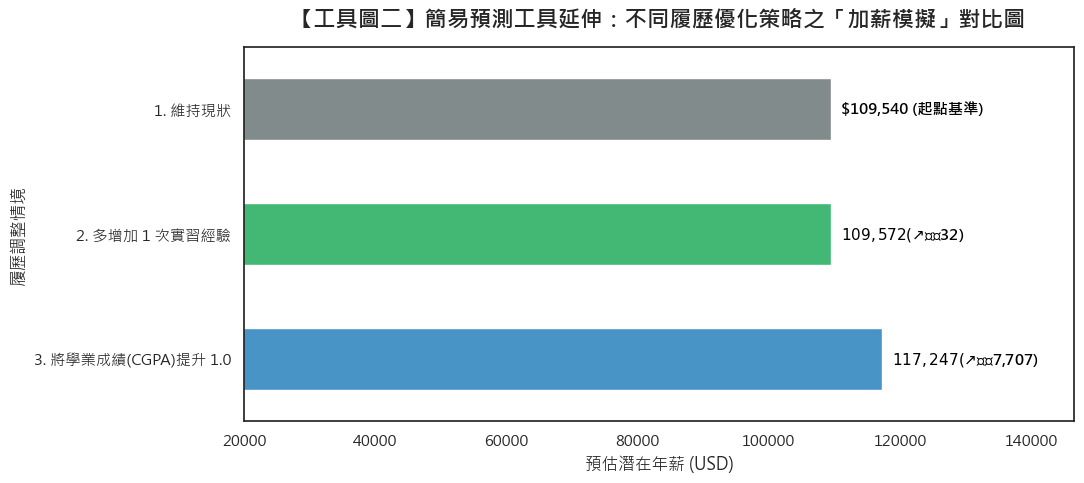

In [46]:
# 基於剛才的 my_background，模擬三種不同職涯策略情境
scenarios = ['1. 維持現狀', '2. 多增加 1 次實習經驗', '3. 將學業成績(CGPA)提升 1.0']

# 情境1：維持現狀
sal_1, _ = predict_student_salary_tool(my_background)

# 情境2：多實習一次
bg_more_intern = my_background.copy()
bg_more_intern['internship_count'] = min(my_background['internship_count'] + 1, 5) # 最高5次
sal_2, _ = predict_student_salary_tool(bg_more_intern)

# 情境3：學成成績提升
bg_better_cgpa = my_background.copy()
bg_better_cgpa['cgpa'] = min(my_background['cgpa'] + 1.0, 10.0) # 最高10.0
sal_3, _ = predict_student_salary_tool(bg_better_cgpa)

salary_results = [sal_1, sal_2, sal_3]

# 繪製圖表二（橫向長條圖）
plt.figure(figsize=(11, 5))
colors = ['#7f8c8d', '#2ecc71', '#3498db'] # 灰色、綠色、藍色

ax = sns.barplot(x=salary_results, y=scenarios, palette=colors, width=0.5)

# 在長條圖右側標上預估的金額與加薪幅度
for i, val in enumerate(salary_results):
    increase = val - sal_1
    if increase > 0:
        label_text = f"${val:,.0f} (↗ 加薪 ${increase:,.0f})"
    else:
        label_text = f"${val:,.0f} (起點基準)"
    plt.text(val + 1500, i, label_text, va='center', fontweight='bold', fontsize=11, color='black')

plt.title('【工具圖二】簡易預測工具延伸：不同履歷優化策略之「加薪模擬」對比圖', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('預估潛在年薪 (USD)', fontsize=12)
plt.ylabel('履歷調整情境', fontsize=12)
plt.xlim(20000, max(salary_results) * 1.25) # 留白給文字標籤
plt.tight_layout()
plt.show()